In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [4]:
path = Path("C:/Data_Projects/F1_Data_team_seperation/f1_data_2023/lap_features_labeled.csv")

df = pd.read_csv(path)

In [5]:
print(df.shape)
print(df.info())
df.head()

(1506, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   session_key         1506 non-null   int64  
 1   driver_number       1506 non-null   int64  
 2   lap_number          1506 non-null   int64  
 3   date_start          1506 non-null   object 
 4   lap_duration        1506 non-null   float64
 5   duration_sector_1   1506 non-null   float64
 6   duration_sector_2   1506 non-null   float64
 7   duration_sector_3   1506 non-null   float64
 8   i1_speed            1503 non-null   float64
 9   i2_speed            1506 non-null   float64
 10  st_speed            1505 non-null   float64
 11  avg_throttle        1506 non-null   float64
 12  throttle_std        1506 non-null   float64
 13  pct_full_throttle   1506 non-null   float64
 14  pct_zero_throttle   1506 non-null   float64
 15  pct_braking         1506 non-null   float64


,session_key,driver_number,lap_number,date_start,lap_duration,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,...,pct_100_200,pct_below_100,pct_drs_active,n_samples,n_gear_changes,team_name,driver_name,country_name,circuit_short_name,location
0,9074,31,17,2023-05-06 20:50:19.053,87.935,29.363,33.504,25.068,223.0,193.0,...,0.290030,0.105740,0.214502,331,35.0,Alpine,Esteban OCON,United States,Miami,Miami
1,9074,77,7,2023-05-06 20:13:12.702,88.058,29.549,33.473,25.036,225.0,195.0,...,0.297872,0.088146,0.224924,329,29.0,Alfa Romeo,Valtteri BOTTAS,United States,Miami,Miami
2,9074,81,8,2023-05-06 20:17:06.667,88.484,29.756,33.681,25.047,219.0,194.0,...,0.290123,0.111111,0.212963,324,36.0,McLaren,Oscar PIASTRI,United States,Miami,Miami
3,9153,2,8,2023-09-02 14:17:23.932,81.930,26.940,27.774,27.216,NaN,339.0,...,0.182965,0.050473,0.192429,317,35.0,Williams,Logan SARGEANT,Italy,Monza,Monza
4,9153,16,5,2023-09-02 14:10:36.281,81.996,27.244,27.664,27.088,320.0,336.0,...,0.153061,0.051020,0.204082,294,31.0,Ferrari,Charles LECLERC,Italy,Monza,Monza


In [6]:
driver_groups = {name: group for name, group in df.groupby('driver_name')}

for name, group in driver_groups.items():
    var_name = name.lower().replace(" ", "_").replace("-", "_")
    globals()[var_name] = group
print(list(driver_groups.keys()))

['Alexander ALBON', 'Carlos SAINZ', 'Charles LECLERC', 'Daniel RICCIARDO', 'Esteban OCON', 'Fernando ALONSO', 'George RUSSELL', 'Kevin MAGNUSSEN', 'Lance STROLL', 'Lando NORRIS', 'Lewis HAMILTON', 'Liam LAWSON', 'Logan SARGEANT', 'Max VERSTAPPEN', 'Nico HULKENBERG', 'Nyck DE VRIES', 'Oscar PIASTRI', 'Pierre GASLY', 'Sergio PEREZ', 'Valtteri BOTTAS', 'Yuki TSUNODA', 'ZHOU Guanyu']


In [ ]:
df["driver_name"].unique()

array(['Esteban OCON', 'Valtteri BOTTAS', 'Oscar PIASTRI',
       'Logan SARGEANT', 'Charles LECLERC', 'Pierre GASLY',
       'Fernando ALONSO', 'Lando NORRIS', 'Daniel RICCIARDO',
       'Yuki TSUNODA', 'ZHOU Guanyu', 'Carlos SAINZ', 'George RUSSELL',
       'Max VERSTAPPEN', 'Lance STROLL', 'Nyck DE VRIES', 'Liam LAWSON',
       'Kevin MAGNUSSEN', 'Lewis HAMILTON', 'Alexander ALBON',
       'Nico HULKENBERG', 'Sergio PEREZ'], dtype=object)

## Driver Scorecard — per race

One row per driver per race (session), summarizing pace, consistency, speed, and driving style.

In [15]:
group_cols = ['session_key', 'circuit_short_name', 'driver_name', 'team_name']

scorecard = df.groupby(group_cols).agg(
    n_laps=('lap_duration', 'count'),
    best_lap=('lap_duration', 'min'),
    avg_lap=('lap_duration', 'mean'),
    lap_consistency=('lap_duration', 'std'),
    avg_sector_1=('duration_sector_1', 'mean'),
    avg_sector_2=('duration_sector_2', 'mean'),
    avg_sector_3=('duration_sector_3', 'mean'),
    top_speed=('max_speed', 'max'),
    avg_speed=('avg_speed', 'mean'),
    speed_trap=('st_speed', 'max'),
    avg_throttle=('avg_throttle', 'mean'),
    pct_full_throttle=('pct_full_throttle', 'mean'),
    pct_braking=('pct_braking', 'mean'),
    avg_gear_changes=('n_gear_changes', 'mean'),
    pct_drs_active=('pct_drs_active', 'mean'),
).reset_index()

# lap_consistency is NaN when a driver only has 1 lap in a session — fill with 0
scorecard['lap_consistency'] = scorecard['lap_consistency'].fillna(0)

round_cols = scorecard.select_dtypes('float').columns
scorecard[round_cols] = scorecard[round_cols].round(2)

scorecard = scorecard.sort_values(['session_key', 'best_lap'])

scorecard

,session_key,circuit_short_name,driver_name,team_name,n_laps,best_lap,avg_lap,lap_consistency,avg_sector_1,avg_sector_2,avg_sector_3,top_speed,avg_speed,speed_trap,avg_throttle,pct_full_throttle,pct_braking,avg_gear_changes,pct_drs_active
11,7768,Sakhir,Max VERSTAPPEN,Red Bull Racing,4,89.71,90.35,0.72,28.88,38.82,22.65,324,213.75,323.0,70.91,0.62,0.19,47.75,0.23
16,7768,Sakhir,Sergio PEREZ,Red Bull Racing,4,89.85,90.55,0.72,28.94,38.92,22.69,325,214.43,324.0,70.97,0.62,0.19,48.50,0.24
2,7768,Sakhir,Charles LECLERC,Ferrari,4,90.00,90.77,0.77,29.03,38.98,22.76,327,213.26,325.0,72.60,0.34,0.18,47.50,0.23
1,7768,Sakhir,Carlos SAINZ,Ferrari,6,90.15,90.98,0.84,28.96,39.20,22.83,330,212.77,326.0,71.06,0.02,0.18,42.67,0.23
4,7768,Sakhir,Fernando ALONSO,Aston Martin,5,90.34,90.89,0.39,29.08,39.02,22.79,322,212.69,320.0,71.17,0.01,0.17,52.80,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,9314,Las Vegas,Lando NORRIS,McLaren,2,94.70,95.08,0.53,27.18,31.53,36.36,342,231.12,338.0,71.67,0.01,0.14,36.00,0.16
282,9314,Las Vegas,Esteban OCON,Alpine,3,94.83,95.11,0.28,27.42,31.54,36.14,352,232.00,338.0,74.10,0.63,0.19,38.00,0.16
292,9314,Las Vegas,Oscar PIASTRI,McLaren,4,94.85,95.21,0.39,27.13,31.77,36.32,344,231.08,340.0,71.27,0.02,0.16,38.75,0.16
297,9314,Las Vegas,ZHOU Guanyu,Alfa Romeo,4,94.85,95.75,0.90,27.54,31.88,36.33,355,231.01,331.0,70.85,0.62,0.18,44.25,0.15


## Team Scorecard — per race

Same stats, rolled up to team level (both drivers' laps combined) per race — for comparing team "fingerprints" against the clustering results.

In [14]:
team_group_cols = ['session_key', 'circuit_short_name', 'team_name']

team_scorecard = df.groupby(team_group_cols).agg(
    n_drivers=('driver_name', 'nunique'),
    n_laps=('lap_duration', 'count'),
    best_lap=('lap_duration', 'min'),
    avg_lap=('lap_duration', 'mean'),
    lap_consistency=('lap_duration', 'std'),
    avg_sector_1=('duration_sector_1', 'mean'),
    avg_sector_2=('duration_sector_2', 'mean'),
    avg_sector_3=('duration_sector_3', 'mean'),
    top_speed=('max_speed', 'max'),
    avg_speed=('avg_speed', 'mean'),
    speed_trap=('st_speed', 'max'),
    avg_throttle=('avg_throttle', 'mean'),
    pct_full_throttle=('pct_full_throttle', 'mean'),
    pct_braking=('pct_braking', 'mean'),
    avg_gear_changes=('n_gear_changes', 'mean'),
    pct_drs_active=('pct_drs_active', 'mean'),
).reset_index()

team_scorecard['lap_consistency'] = team_scorecard['lap_consistency'].fillna(0)

round_cols = team_scorecard.select_dtypes('float').columns
team_scorecard[round_cols] = team_scorecard[round_cols].round(2)

team_scorecard = team_scorecard.sort_values(['session_key', 'best_lap'])

team_scorecard

,session_key,circuit_short_name,team_name,n_drivers,n_laps,best_lap,avg_lap,lap_consistency,avg_sector_1,avg_sector_2,avg_sector_3,top_speed,avg_speed,speed_trap,avg_throttle,pct_full_throttle,pct_braking,avg_gear_changes,pct_drs_active
8,7768,Sakhir,Red Bull Racing,2,8,89.71,90.45,0.67,28.91,38.87,22.67,325,214.09,324.0,70.94,0.62,0.19,48.12,0.23
4,7768,Sakhir,Ferrari,2,10,90.00,90.90,0.78,28.99,39.11,22.80,330,212.96,326.0,71.68,0.15,0.18,44.60,0.23
3,7768,Sakhir,Aston Martin,2,11,90.34,91.22,0.56,29.15,39.25,22.83,322,212.11,320.0,70.72,0.01,0.18,49.00,0.24
7,7768,Sakhir,Mercedes,2,10,90.34,90.97,0.53,29.01,39.17,22.79,325,212.91,324.0,71.30,0.59,0.19,48.20,0.24
5,7768,Sakhir,Haas F1 Team,2,7,90.81,91.62,0.59,29.29,39.34,22.99,322,212.44,318.0,70.27,0.38,0.19,46.43,0.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,9314,Las Vegas,Alfa Romeo,2,10,93.52,95.03,1.11,27.22,31.62,36.19,355,233.09,347.0,72.20,0.63,0.17,40.50,0.16
145,9314,Las Vegas,Haas F1 Team,2,14,93.54,94.60,0.87,26.80,31.39,36.41,348,234.24,342.0,74.46,0.59,0.16,38.79,0.17
143,9314,Las Vegas,Aston Martin,2,12,93.56,94.47,0.75,26.80,31.46,36.21,346,233.74,344.0,73.75,0.21,0.16,42.58,0.17
141,9314,Las Vegas,AlphaTauri,2,7,94.31,95.64,0.98,27.45,31.89,36.31,349,231.02,342.0,72.37,0.63,0.17,41.57,0.16


## Team-vs-Team Comparison (analytics, no ML)

Two problems with comparing raw feature averages across the season:
1. Circuits differ hugely (Monaco laps ~70s, Spa ~104s), so raw lap times aren't comparable across races.
2. Percentage-type features (`pct_full_throttle`, `pct_braking`, `pct_drs_active`) are bounded near 0 for some laps (in-laps, wet laps, safety car), so a ratio-based "% vs average" blows up asymmetrically for them.

Fix: convert every feature to a **z-score within its own session** (standard deviations above/below that race's field average), then average those z-scores across all 15 races per team. This keeps every feature on the same comparable scale and avoids the division blowup.

Example pair: **Red Bull Racing vs Mercedes**.

In [16]:
# Features to compare, and how to read the sign:
# positive = "better/more" than the session field average, for all of these
feat_cols = ['lap_duration', 'max_speed', 'avg_speed', 'avg_throttle',
             'pct_full_throttle', 'pct_braking', 'n_gear_changes', 'pct_drs_active']

session_mean = df.groupby('session_key')[feat_cols].transform('mean')
session_std = df.groupby('session_key')[feat_cols].transform('std')
z = (df[feat_cols] - session_mean) / session_std
z['lap_duration'] = -z['lap_duration']  # flip: lower lap time = better, so negate
z['team_name'] = df['team_name']

team_profile = z.groupby('team_name')[feat_cols].mean().round(2)
team_profile = team_profile.rename(columns={
    'lap_duration': 'pace',
    'max_speed': 'top_speed',
    'n_gear_changes': 'gear_changes',
})
team_profile.columns.name = 'feature (z-score vs field average)'
team_profile.sort_values('pace', ascending=False)

feature (z-score vs field average),pace,top_speed,avg_speed,avg_throttle,pct_full_throttle,pct_braking,gear_changes,pct_drs_active
team_name,,,,,,,,
Red Bull Racing,0.70,0.58,0.50,-0.02,0.74,-0.17,-0.41,-0.05
Ferrari,0.52,0.56,0.43,0.88,-0.94,0.42,-0.24,0.07
Mercedes,0.29,-0.41,0.20,0.59,0.67,-0.09,0.26,0.18
McLaren,0.11,-0.31,0.17,-0.84,-1.46,-0.63,-0.04,0.04
Aston Martin,-0.04,-0.45,-0.20,-0.11,-1.16,-0.12,1.28,0.05
Alpine,-0.17,-0.23,-0.18,0.11,0.60,0.27,-0.06,0.02
Haas F1 Team,-0.35,0.49,-0.10,-0.12,0.26,0.04,-0.27,0.05
Alfa Romeo,-0.50,-0.01,-0.28,0.13,0.64,0.24,-0.34,-0.14
AlphaTauri,-0.50,-0.83,-0.42,0.17,0.61,-0.60,-0.47,-0.05


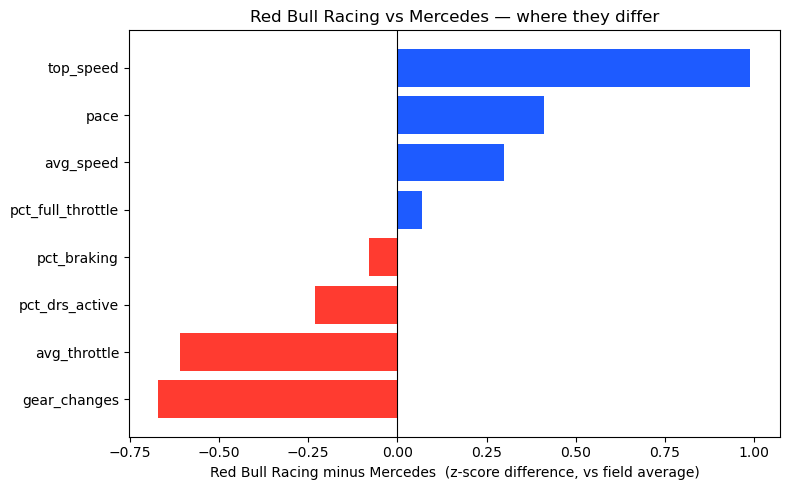

In [17]:
# Diverging bar: precise, per-feature difference between two teams
team_a, team_b = 'Red Bull Racing', 'Mercedes'

diff = (team_profile.loc[team_a] - team_profile.loc[team_b]).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1E5BFF' if v > 0 else '#FF3B30' for v in diff]
ax.barh(diff.index, diff.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'{team_a} minus {team_b}  (z-score difference, vs field average)')
ax.set_title(f'{team_a} vs {team_b} — where they differ')
plt.tight_layout()
plt.show()

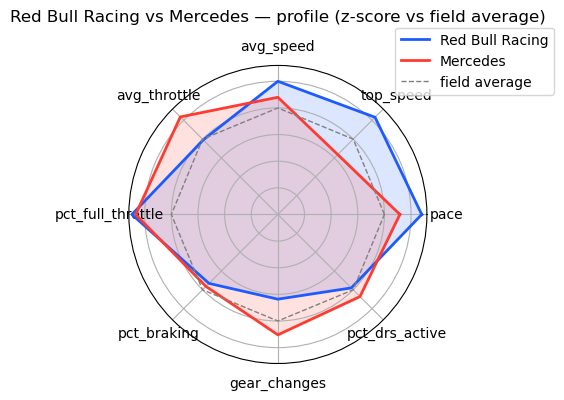

In [18]:
# Radar chart: intuitive "shape" comparison, app-facing
#
# z-scores are signed (negative = below average), and matplotlib's polar axes
# render a negative radius by flipping to the opposite side of the circle,
# which distorts the shape. Fix: shift every value by a constant so the plotted
# radius is always >= 0, and draw a dashed circle at that shift to mark "average".
categories = list(team_profile.columns)
n = len(categories)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

shift = 2  # comfortably above the largest |z-score| in team_profile (~1.5)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for team, color in [(team_a, '#1E5BFF'), (team_b, '#FF3B30')]:
    values = (team_profile.loc[team, categories] + shift).tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=team)
    ax.fill(angles, values, color=color, alpha=0.15)

# reference circle at the shifted "zero" = field average
ax.plot(angles, [shift] * len(angles), color='gray', linestyle='--', linewidth=1, label='field average')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticklabels([])  # raw ticks are shifted values, not meaningful on their own
ax.set_title(f'{team_a} vs {team_b} — profile (z-score vs field average)', y=1.12)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15))
plt.tight_layout()
plt.show()